## HW1: Классификация вредоносного ПО по артефактам памяти (MLP)

Гандзюк Д.А. AITH



In [ ]:
import os
import random
from dataclasses import dataclass

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report

import matplotlib.pyplot as plt


@dataclass
class Config:
    seed: int = 42
    test_size: float = 0.2
    val_size: float = 0.2
    batch_size: int = 256
    lr: float = 1e-3
    epochs: int = 50
    patience: int = 10  # early stopping по val loss


cfg = Config()


def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed(cfg.seed)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device



device(type='cuda')

## 1) Загрузка данных и базовая проверка

Проверим размеры датасета, типы признаков и баланс классов. Баланс важен, поэтому разбиение делаем со **стратификацией** по `Class`.



In [12]:
possible_paths = [
    "cybersequrity.csv",  
    os.path.join("hw_1", "cybersequrity.csv"),  
]
data_path = None
for path in possible_paths:
    if os.path.exists(path):
        data_path = path
        break
if data_path is None:
    raise FileNotFoundError(f"Не найден файл. Рабочая директория: {os.getcwd()}")
print(f"Загружаем данные из: {data_path}")
df = pd.read_csv(data_path)

print("shape:", df.shape)
display(df.head())

print("\nDtypes:")
display(df.dtypes)

print("\nClass distribution:")
class_counts = df["Class"].value_counts().sort_index()
class_freq = df["Class"].value_counts(normalize=True).sort_index()
display(pd.DataFrame({"count": class_counts, "freq": class_freq}))

print("\nMissing values:")
display(df.isna().sum().sort_values(ascending=False).head(10))


Загружаем данные из: cybersequrity.csv
shape: (10000, 16)


,svcscan.fs_drivers,callbacks.ngeneric,psxview.not_in_eprocess_pool_false_avg,psxview.not_in_eprocess_pool,callbacks.nanonymous,psxview.not_in_session,psxview.not_in_pslist,psxview.not_in_pspcid_list,psxview.not_in_ethread_pool,psxview.not_in_csrss_handles,psxview.not_in_pslist_false_avg,psxview.not_in_pspcid_list_false_avg,psxview.not_in_deskthrd,psxview.not_in_ethread_pool_false_avg,psxview.not_in_session_false_avg,Class
0,26,8,0.0,0,0,2,0,0,0,4,0.000000,0.000000,6,0.000000,0.044444,1
1,26,8,0.0,0,0,5,3,3,3,7,0.073171,0.073171,9,0.073171,0.121951,1
2,26,8,0.0,0,0,9,7,7,7,11,0.152174,0.152174,13,0.152174,0.195652,1
3,26,8,0.0,0,0,3,1,1,2,6,0.022222,0.022222,9,0.044444,0.066667,1
4,26,8,0.0,0,0,2,0,0,0,4,0.000000,0.000000,6,0.000000,0.048780,0



Dtypes:


svcscan.fs_drivers                          int64
callbacks.ngeneric                          int64
psxview.not_in_eprocess_pool_false_avg    float64
psxview.not_in_eprocess_pool                int64
callbacks.nanonymous                        int64
psxview.not_in_session                      int64
psxview.not_in_pslist                       int64
psxview.not_in_pspcid_list                  int64
psxview.not_in_ethread_pool                 int64
psxview.not_in_csrss_handles                int64
psxview.not_in_pslist_false_avg           float64
psxview.not_in_pspcid_list_false_avg      float64
psxview.not_in_deskthrd                     int64
psxview.not_in_ethread_pool_false_avg     float64
psxview.not_in_session_false_avg          float64
Class                                       int64
dtype: object


Class distribution:


,count,freq
Class,,
0,4904,0.4904
1,5096,0.5096



Missing values:


svcscan.fs_drivers                        0
callbacks.ngeneric                        0
psxview.not_in_eprocess_pool_false_avg    0
psxview.not_in_eprocess_pool              0
callbacks.nanonymous                      0
psxview.not_in_session                    0
psxview.not_in_pslist                     0
psxview.not_in_pspcid_list                0
psxview.not_in_ethread_pool               0
psxview.not_in_csrss_handles              0
dtype: int64

## 2) Подготовка данных (split + стандартизация)

- **Разбиение 60/20/20 со стратификацией** делаем в 2 шага: сначала отделяем test=20%, затем из оставшихся 80% отделяем val=25% .
- Стандартизируем входные признаки благодаря hint хи-хи.
- Важно: `StandardScaler` **fit только на train**, затем `transform` на val/test (чтобы избежать утечки информации).



In [ ]:
target_col = "Class"
feature_cols = [c for c in df.columns if c != target_col]

X = df[feature_cols].astype(np.float32).values
y = df[target_col].astype(np.float32).values

# 1) train (60%) vs temp (40%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=cfg.val_size + cfg.test_size,
    random_state=cfg.seed,
    stratify=y,
)

# 2) temp (40%) -> val (20%) + test (20%)
# доля test внутри temp = 0.5 (потому что хотим 20% из 40%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=cfg.seed,
    stratify=y_temp,
)

print("Shapes:")
print("train:", X_train.shape, y_train.shape)
print("val:  ", X_val.shape, y_val.shape)
print("test: ", X_test.shape, y_test.shape)

print("\nClass freq (train/val/test):")
for name, yy in [("train", y_train), ("val", y_val), ("test", y_test)]:
    freq = pd.Series(yy).value_counts(normalize=True).sort_index()
    print(name, dict(freq))

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train).astype(np.float32)
X_val_s = scaler.transform(X_val).astype(np.float32)
X_test_s = scaler.transform(X_test).astype(np.float32)



Shapes:
train: (6000, 15) (6000,)
val:   (2000, 15) (2000,)
test:  (2000, 15) (2000,)

Class freq (train/val/test):
train {0.0: np.float64(0.49033333333333334), 1.0: np.float64(0.5096666666666667)}
val {0.0: np.float64(0.4905), 1.0: np.float64(0.5095)}
test {0.0: np.float64(0.4905), 1.0: np.float64(0.5095)}


## 3) PyTorch Dataset / DataLoader

**Почему `batch_size=256`:** датасет небольшой (10k строк, 15 признаков), поэтому крупный batch даёт хорошую загрузку GPU/CPU и более стабильные оценки градиента. На практике для табличных задач обычно хорошо работают значения 128-512; дальше можно подстроить под доступную память.

На винде (я на винде) часто удобнее оставить `num_workers=0`, чтобы избежать проблем с многопроцессной загрузкой данных в ноутбуке.



In [5]:
class MalwareDataset(Dataset):
    def __init__(self, X: np.ndarray, y: np.ndarray):
        self.X = torch.from_numpy(X).float()
        # BCELoss ожидает float-таргет той же формы, что и предсказание
        self.y = torch.from_numpy(y).float().view(-1, 1)

    def __len__(self) -> int:
        return self.X.shape[0]

    def __getitem__(self, idx: int):
        return self.X[idx], self.y[idx]


train_ds = MalwareDataset(X_train_s, y_train)
val_ds = MalwareDataset(X_val_s, y_val)
test_ds = MalwareDataset(X_test_s, y_test)

pin_memory = (device.type == "cuda")

train_loader = DataLoader(
    train_ds,
    batch_size=cfg.batch_size,
    shuffle=True,
    num_workers=0,
    pin_memory=pin_memory,
)
val_loader = DataLoader(
    val_ds,
    batch_size=cfg.batch_size,
    shuffle=False,
    num_workers=0,
    pin_memory=pin_memory,
)
test_loader = DataLoader(
    test_ds,
    batch_size=cfg.batch_size,
    shuffle=False,
    num_workers=0,
    pin_memory=pin_memory,
)

next(iter(train_loader))[0].shape, next(iter(train_loader))[1].shape



(torch.Size([256, 15]), torch.Size([256, 1]))

## 4) Бейзлайновая модель MLP

Выбираем простой бейзлайн для табличных данных:

- **2 скрытых слоя** (умеренная ёмкость, чтобы не переусложнять baseline)
- **ReLU** как стандартная устойчивая активация
- **Sigmoid на выходе**, т.к. используем `nn.BCELoss` (ожидает вероятности в [0,1])



In [6]:
class BaselineMLP(nn.Module):
    def __init__(self, input_dim: int, hidden_dims=(64, 32)):
        super().__init__()
        h1, h2 = hidden_dims
        self.net = nn.Sequential(
            nn.Linear(input_dim, h1),
            nn.ReLU(),
            nn.Linear(h1, h2),
            nn.ReLU(),
            nn.Linear(h2, 1),
            nn.Sigmoid(),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


input_dim = X_train_s.shape[1]
model = BaselineMLP(input_dim=input_dim, hidden_dims=(64, 32)).to(device)
model



BaselineMLP(
  (net): Sequential(
    (0): Linear(in_features=15, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=1, bias=True)
    (5): Sigmoid()
  )
)

## 5) Train-loop / Eval-loop + графики loss

- Используем `Adam` как стабильный оптимизатор для табличных нейросетей.
- Лучшую модель выбираем по **минимальному val loss**.
- Для контроля обучения сохраняем историю `train_loss` и `val_loss` и строим график.



In [7]:
def run_epoch_train(model: nn.Module, loader: DataLoader, optimizer: torch.optim.Optimizer, criterion: nn.Module) -> float:
    model.train()
    total_loss = 0.0
    n = 0

    for Xb, yb in loader:
        Xb = Xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        pred = model(Xb)
        loss = criterion(pred, yb)
        loss.backward()
        optimizer.step()

        bs = Xb.size(0)
        total_loss += loss.item() * bs
        n += bs

    return total_loss / max(1, n)


@torch.no_grad()
def run_epoch_eval(model: nn.Module, loader: DataLoader, criterion: nn.Module) -> float:
    model.eval()
    total_loss = 0.0
    n = 0

    for Xb, yb in loader:
        Xb = Xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)

        pred = model(Xb)
        loss = criterion(pred, yb)

        bs = Xb.size(0)
        total_loss += loss.item() * bs
        n += bs

    return total_loss / max(1, n)


def fit(model: nn.Module, train_loader: DataLoader, val_loader: DataLoader, lr: float, epochs: int, patience: int):
    criterion = nn.BCELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    history = {"train_loss": [], "val_loss": []}

    best_val = float("inf")
    best_state = None
    bad_epochs = 0

    for epoch in range(1, epochs + 1):
        tr = run_epoch_train(model, train_loader, optimizer, criterion)
        va = run_epoch_eval(model, val_loader, criterion)

        history["train_loss"].append(tr)
        history["val_loss"].append(va)

        if va < best_val - 1e-6:
            best_val = va
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            bad_epochs = 0
        else:
            bad_epochs += 1

        if epoch % 5 == 0 or epoch == 1:
            print(f"Epoch {epoch:03d}/{epochs}: train_loss={tr:.4f} val_loss={va:.4f}")

        if bad_epochs >= patience:
            print(f"Early stopping: нет улучшений {patience} эпох подряд")
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    return history


def plot_losses(history, title="Loss динамика"):
    plt.figure(figsize=(7, 4))
    plt.plot(history["train_loss"], label="train")
    plt.plot(history["val_loss"], label="val")
    plt.xlabel("epoch")
    plt.ylabel("BCELoss")
    plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.show()



Epoch 001/50: train_loss=0.6858 val_loss=0.6788
Epoch 005/50: train_loss=0.6553 val_loss=0.6531
Epoch 010/50: train_loss=0.6200 val_loss=0.6194
Epoch 015/50: train_loss=0.5693 val_loss=0.5681
Epoch 020/50: train_loss=0.5299 val_loss=0.5250
Epoch 025/50: train_loss=0.5074 val_loss=0.5034
Epoch 030/50: train_loss=0.4918 val_loss=0.4905
Epoch 035/50: train_loss=0.4789 val_loss=0.4761
Epoch 040/50: train_loss=0.4708 val_loss=0.4680
Epoch 045/50: train_loss=0.4638 val_loss=0.4621
Epoch 050/50: train_loss=0.4569 val_loss=0.4569


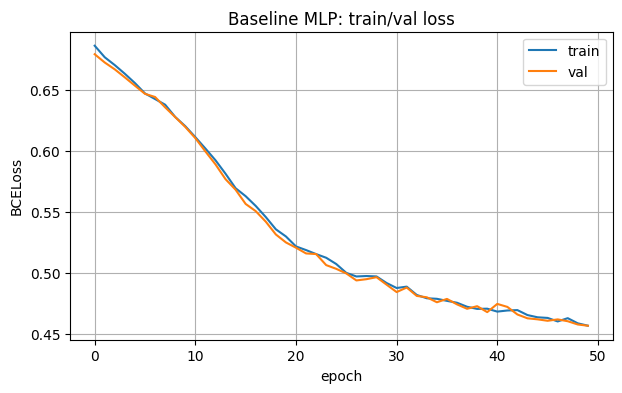

In [8]:
# Обучаем бейзлайн
set_seed(cfg.seed)
model = BaselineMLP(input_dim=input_dim, hidden_dims=(64, 32)).to(device)

history_base = fit(
    model,
    train_loader=train_loader,
    val_loader=val_loader,
    lr=cfg.lr,
    epochs=cfg.epochs,
    patience=cfg.patience,
)

plot_losses(history_base, title="Baseline MLP: train/val loss")


In [9]:
@torch.no_grad()
def predict_proba(model: nn.Module, loader: DataLoader) -> np.ndarray:
    model.eval()
    probs = []
    for Xb, _ in loader:
        Xb = Xb.to(device, non_blocking=True)
        pb = model(Xb).detach().cpu().numpy().reshape(-1)
        probs.append(pb)
    return np.concatenate(probs)


proba_test_base = predict_proba(model, test_loader)
pred_test_base = (proba_test_base >= 0.5).astype(int)

print("Baseline MLP: classification_report (test)")
print(classification_report(y_test.astype(int), pred_test_base, digits=4))



Baseline MLP: classification_report (test)
              precision    recall  f1-score   support

           0     0.7770    0.7992    0.7879       981
           1     0.8012    0.7792    0.7900      1019

    accuracy                         0.7890      2000
   macro avg     0.7891    0.7892    0.7890      2000
weighted avg     0.7893    0.7890    0.7890      2000



## 6) Улучшение модели: BatchNorm1d + Dropout

Идея улучшений:

- **BatchNorm1d** часто ускоряет сходимость и стабилизирует обучение MLP на табличных данных.
  - Типичное расположение: `Linear -> BatchNorm -> Activation`.
- **Dropout** помогает регуляризации (уменьшает переобучение).
  - Типичное расположение: после активации (`... Activation -> Dropout`).

Подберём `p` в небольшом диапазоне (например, 0.1 / 0.3 / 0.5) и выберем вариант по **val loss**.



Epoch 001/80: train_loss=0.6694 val_loss=0.6580
Epoch 005/80: train_loss=0.5332 val_loss=0.5413
Epoch 010/80: train_loss=0.4902 val_loss=0.5019
Epoch 015/80: train_loss=0.4544 val_loss=0.4833
Epoch 020/80: train_loss=0.4552 val_loss=0.4609
Epoch 025/80: train_loss=0.4278 val_loss=0.4625
Epoch 030/80: train_loss=0.4237 val_loss=0.4367
Epoch 035/80: train_loss=0.4134 val_loss=0.4428
Epoch 040/80: train_loss=0.4019 val_loss=0.4340
Epoch 045/80: train_loss=0.4050 val_loss=0.4050
Epoch 050/80: train_loss=0.3933 val_loss=0.3958
Epoch 055/80: train_loss=0.3860 val_loss=0.3808
Epoch 060/80: train_loss=0.3881 val_loss=0.3979
Early stopping: нет улучшений 12 эпох подряд


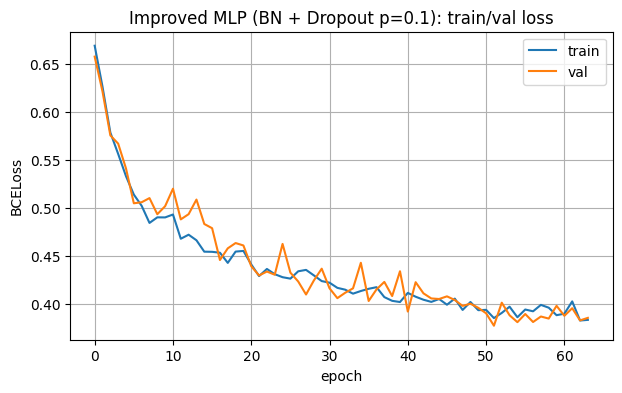

Epoch 001/80: train_loss=0.6783 val_loss=0.6657
Epoch 005/80: train_loss=0.5681 val_loss=0.5597
Epoch 010/80: train_loss=0.5216 val_loss=0.5030
Epoch 015/80: train_loss=0.4973 val_loss=0.4938
Epoch 020/80: train_loss=0.4863 val_loss=0.4793
Epoch 025/80: train_loss=0.4682 val_loss=0.4929
Epoch 030/80: train_loss=0.4556 val_loss=0.4641
Epoch 035/80: train_loss=0.4402 val_loss=0.4572
Epoch 040/80: train_loss=0.4441 val_loss=0.4423
Epoch 045/80: train_loss=0.4323 val_loss=0.4314
Epoch 050/80: train_loss=0.4320 val_loss=0.4238
Epoch 055/80: train_loss=0.4308 val_loss=0.4132
Epoch 060/80: train_loss=0.4244 val_loss=0.4125
Epoch 065/80: train_loss=0.4278 val_loss=0.4231
Epoch 070/80: train_loss=0.4200 val_loss=0.4019
Epoch 075/80: train_loss=0.4167 val_loss=0.3981
Epoch 080/80: train_loss=0.4084 val_loss=0.3881


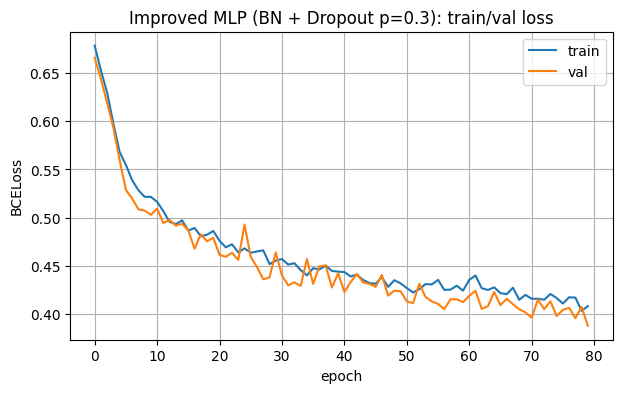

Epoch 001/80: train_loss=0.6919 val_loss=0.6752
Epoch 005/80: train_loss=0.6319 val_loss=0.6148
Epoch 010/80: train_loss=0.5618 val_loss=0.5334
Epoch 015/80: train_loss=0.5279 val_loss=0.5127
Epoch 020/80: train_loss=0.5208 val_loss=0.5019
Epoch 025/80: train_loss=0.5129 val_loss=0.5017
Epoch 030/80: train_loss=0.4970 val_loss=0.4852
Epoch 035/80: train_loss=0.4881 val_loss=0.4766
Epoch 040/80: train_loss=0.4808 val_loss=0.4629
Epoch 045/80: train_loss=0.4736 val_loss=0.4441
Epoch 050/80: train_loss=0.4725 val_loss=0.4479
Epoch 055/80: train_loss=0.4650 val_loss=0.4342
Epoch 060/80: train_loss=0.4653 val_loss=0.4307
Epoch 065/80: train_loss=0.4567 val_loss=0.4536
Epoch 070/80: train_loss=0.4554 val_loss=0.4285
Epoch 075/80: train_loss=0.4478 val_loss=0.4220
Epoch 080/80: train_loss=0.4501 val_loss=0.4162


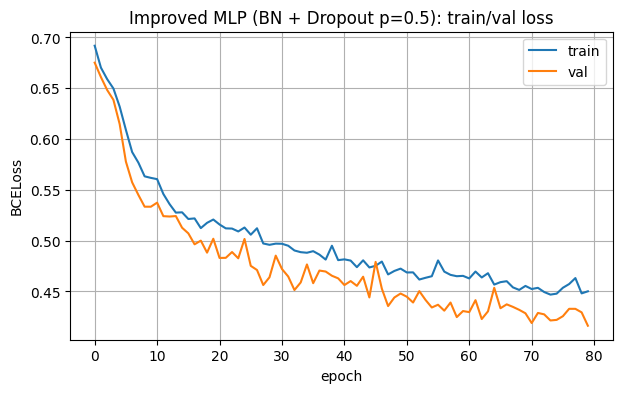

,dropout_p,best_val_loss
0,0.1,0.377108
1,0.3,0.388055
2,0.5,0.416247


Выбран лучший p по val loss: 0.1
Improved MLP: classification_report (test)
              precision    recall  f1-score   support

           0     0.8164    0.8114    0.8139       981
           1     0.8195    0.8243    0.8219      1019

    accuracy                         0.8180      2000
   macro avg     0.8180    0.8179    0.8179      2000
weighted avg     0.8180    0.8180    0.8180      2000



In [ ]:
class ImprovedMLP(nn.Module):
    def __init__(self, input_dim: int, hidden_dims=(128, 64, 32), dropout_p: float = 0.3):
        super().__init__()
        h1, h2, h3 = hidden_dims

        # Linear -> BatchNorm -> Activation -> (Dropout)
        self.net = nn.Sequential(
            nn.Linear(input_dim, h1),
            nn.BatchNorm1d(h1),
            nn.LeakyReLU(0.1),
            nn.Dropout(dropout_p),

            nn.Linear(h1, h2),
            nn.BatchNorm1d(h2),
            nn.LeakyReLU(0.1),
            nn.Dropout(dropout_p),

            nn.Linear(h2, h3),
            nn.BatchNorm1d(h3),
            nn.LeakyReLU(0.1),

            nn.Linear(h3, 1),
            nn.Sigmoid(),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


def train_model(model_ctor, *, lr: float, epochs: int, patience: int, title: str):
    """Обучаем модель и выбираем лучшую по val loss"""
    set_seed(cfg.seed)
    mdl = model_ctor().to(device)
    hist = fit(mdl, train_loader, val_loader, lr=lr, epochs=epochs, patience=patience)
    plot_losses(hist, title=title)

    best_val = float(np.min(hist["val_loss"]))
    return mdl, hist, best_val


dropouts = [0.1, 0.3, 0.5]
rows = []
models = {}

for p in dropouts:
    mdl, hist, best_val = train_model(
        lambda p=p: ImprovedMLP(input_dim=input_dim, hidden_dims=(128, 64, 32), dropout_p=p),
        lr=1e-3,
        epochs=80,
        patience=12,
        title=f"Improved MLP (BN + Dropout p={p}): train/val loss",
    )
    rows.append({"dropout_p": p, "best_val_loss": best_val})
    models[p] = mdl

results_df = pd.DataFrame(rows).sort_values("best_val_loss", ascending=True)
display(results_df)

best_p = float(results_df.iloc[0]["dropout_p"])
best_model = models[best_p]

print("Выбран лучший p по val loss:", best_p)

proba_test_imp = predict_proba(best_model, test_loader)
pred_test_imp = (proba_test_imp >= 0.5).astype(int)

print("Improved MLP: classification_report (test)")
print(classification_report(y_test.astype(int), pred_test_imp, digits=4))



## 7) Выводы по улучшениям и воспроизводимость

### Выводы (BatchNorm / Dropout)

- **BatchNorm1d** обычно помогает MLP: обучение становится стабильнее, а минимум `val loss` достигается быстрее.
- **Dropout** полезен, когда видно переобучение (train loss падает заметно быстрее, чем val loss). Слишком большой `p` (как было с 0.5) может ухудшить качество из-за недообучения.
- **Расположение слоёв**: наиболее практичный вариант для табличного MLP — `Linear -> BatchNorm -> Activation -> Dropout`.

### Воспроизводимость

- Зафиксированы **seed** (`cfg.seed`)

